# Assignment 2 — Synesthesia CIFAR-10: Color Channel Prediction

This notebook trains a CNN to predict one missing RGB channel of a CIFAR-10 image
from the other two, simulating **synesthesia** (cross-sensory prediction).

**Default task:** use Red + Green channels as input → predict **Blue**  
**Bonus:** extend to predict each of R, G, B independently.

| Part | Topic | Points |
|------|-------|--------|
| 1 | Data Exploration and Preprocessing | 25 |
| 2 | Model Design and Implementation | 35 |
| 3 | Training and Optimization | 25 |
| 4 | Evaluation and Analysis | 15 |
| Bonus | Predict R, G, and B | +10 |


## Setup


In [103]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
import os, sys, time
from pathlib import Path
from io import BytesIO
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Use Agg backend (headless) so evaluator imports don't conflict with notebook display
matplotlib.use('Agg')

# ── project imports ────────────────────────────────────────────────────────
import src.config as cfg
from src.data_loader import (
    download_and_extract, build_dataloaders,
    load_all_images, load_test_images,
    load_class_names, CIFARColorDataset, CHANNEL_IDX,
)
from src.model import ColorPredictor, ConvBlock
from src.trainer import train
from src.evaluator import (
    compute_metrics, plot_performance_matrix,
    plot_per_class_metrics, CIFAR10_CLASSES,
)
from src.experiments import run_sweep, SWEEP

# ── helper: display a matplotlib figure inline ─────────────────────────────
def show_fig(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {cfg.DEVICE}')
print(f'Outputs  → {cfg.OUTPUTS_DIR}')


PyTorch  : 2.10.0
Device   : mps
Outputs  → /Users/wang/Documents/deeplearning_assignment2/synesthesia_cifar10/outputs


---
## Part 1 — Data Exploration and Preprocessing

**Dataset:** CIFAR-10 from the University of Toronto  
**Source:** `https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz`  
**Format:** 6 pickle files — 5 training batches (50 000 images) + 1 test batch (10 000)  
**Pre-processing:** uint8 `(N, 3072)` arrays → float32 tensors `(N, 3, 32, 32)` in [0, 1]


### 1-A  Download & Extract


In [105]:
# Download CIFAR-10 (skipped automatically if already present)
cifar_dir   = download_and_extract()
class_names = load_class_names(cifar_dir)
print(f'CIFAR-10 directory : {cifar_dir}')
print(f'Classes ({len(class_names)}): {class_names}')


INFO | CIFAR-10 already extracted at /Users/wang/Documents/deeplearning_assignment2/synesthesia_cifar10/data/cifar-10-batches-py — skipping download.


CIFAR-10 directory : /Users/wang/Documents/deeplearning_assignment2/synesthesia_cifar10/data/cifar-10-batches-py
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1-B  Dataset Statistics


In [106]:
images, labels = load_all_images(cifar_dir)

print(f'Tensor shape   : {tuple(images.shape)}')
print(f'Dtype          : {images.dtype}')
print(f'Pixel range    : [{images.min():.3f}, {images.max():.3f}]')
print(f'Total images   : {len(labels):,}')

print('\nClass distribution (training set):')
counts = Counter(labels)
print(f"  {'ID':<4} {'Class':<14} {'Count':>6}")
print('  ' + '-' * 27)
for i, name in enumerate(class_names):
    print(f'  {i:<4} {name:<14} {counts[i]:>6,}')


INFO | Loading data_batch_1 …
INFO | Loading data_batch_2 …
INFO | Loading data_batch_3 …
INFO | Loading data_batch_4 …
INFO | Loading data_batch_5 …
INFO | Loaded 50,000 images  shape=(50000, 3, 32, 32)


Tensor shape   : (50000, 3, 32, 32)
Dtype          : torch.float32
Pixel range    : [0.000, 1.000]
Total images   : 50,000

Class distribution (training set):
  ID   Class           Count
  ---------------------------
  0    airplane        5,000
  1    automobile      5,000
  2    bird            5,000
  3    cat             5,000
  4    deer            5,000
  5    dog             5,000
  6    frog            5,000
  7    horse           5,000
  8    ship            5,000
  9    truck           5,000


### 1-C  Dataset Split (80 / 10 / 10)


In [107]:
n       = len(images)
n_train = int(n * cfg.TRAIN_RATIO)
n_val   = int(n * cfg.VAL_RATIO)
n_test  = n - n_train - n_val

print(f'Total  : {n:>7,}')
print(f'Train  : {n_train:>7,}  ({cfg.TRAIN_RATIO*100:.0f}%)')
print(f'Val    : {n_val:>7,}  ({cfg.VAL_RATIO*100:.0f}%)')
print(f'Test   : {n_test:>7,}  ({(1-cfg.TRAIN_RATIO-cfg.VAL_RATIO)*100:.0f}%)')
print(f'Seed   : {cfg.RANDOM_SEED}')
print(f'Target channel: {cfg.TARGET_CHANNEL}  '
      f'(predict {cfg.TARGET_CHANNEL} from '
      f'{"+".join(ch for ch in "RGB" if ch != cfg.TARGET_CHANNEL)})')


Total  :  50,000
Train  :  40,000  (80%)
Val    :   5,000  (10%)
Test   :   5,000  (10%)
Seed   : 42
Target channel: B  (predict B from R+G)


### 1-D  Sample Images


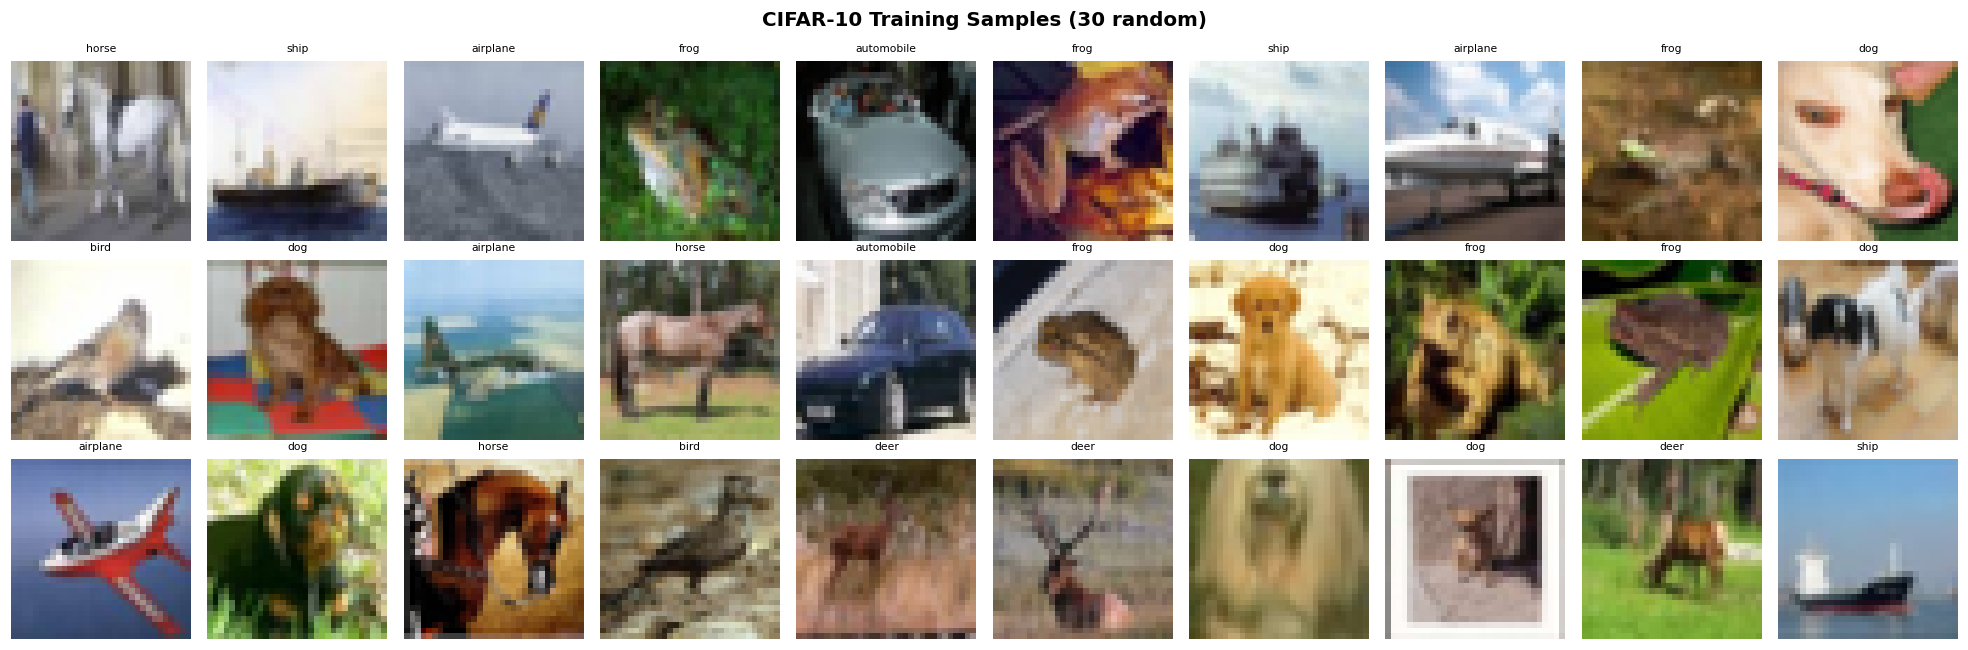

In [108]:
np.random.seed(42)
idx = np.random.choice(len(images), 30, replace=False)

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('CIFAR-10 Training Samples (30 random)', fontsize=13, fontweight='bold')
for ax, i in zip(axes.flat, idx):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.set_title(class_names[labels[i]], fontsize=7)
    ax.axis('off')
plt.tight_layout()
show_fig(fig)


### 1-E  RGB Channel Decomposition

For each CIFAR-10 image, we separate the three colour planes.  
The model receives two channels as input and must predict the third.


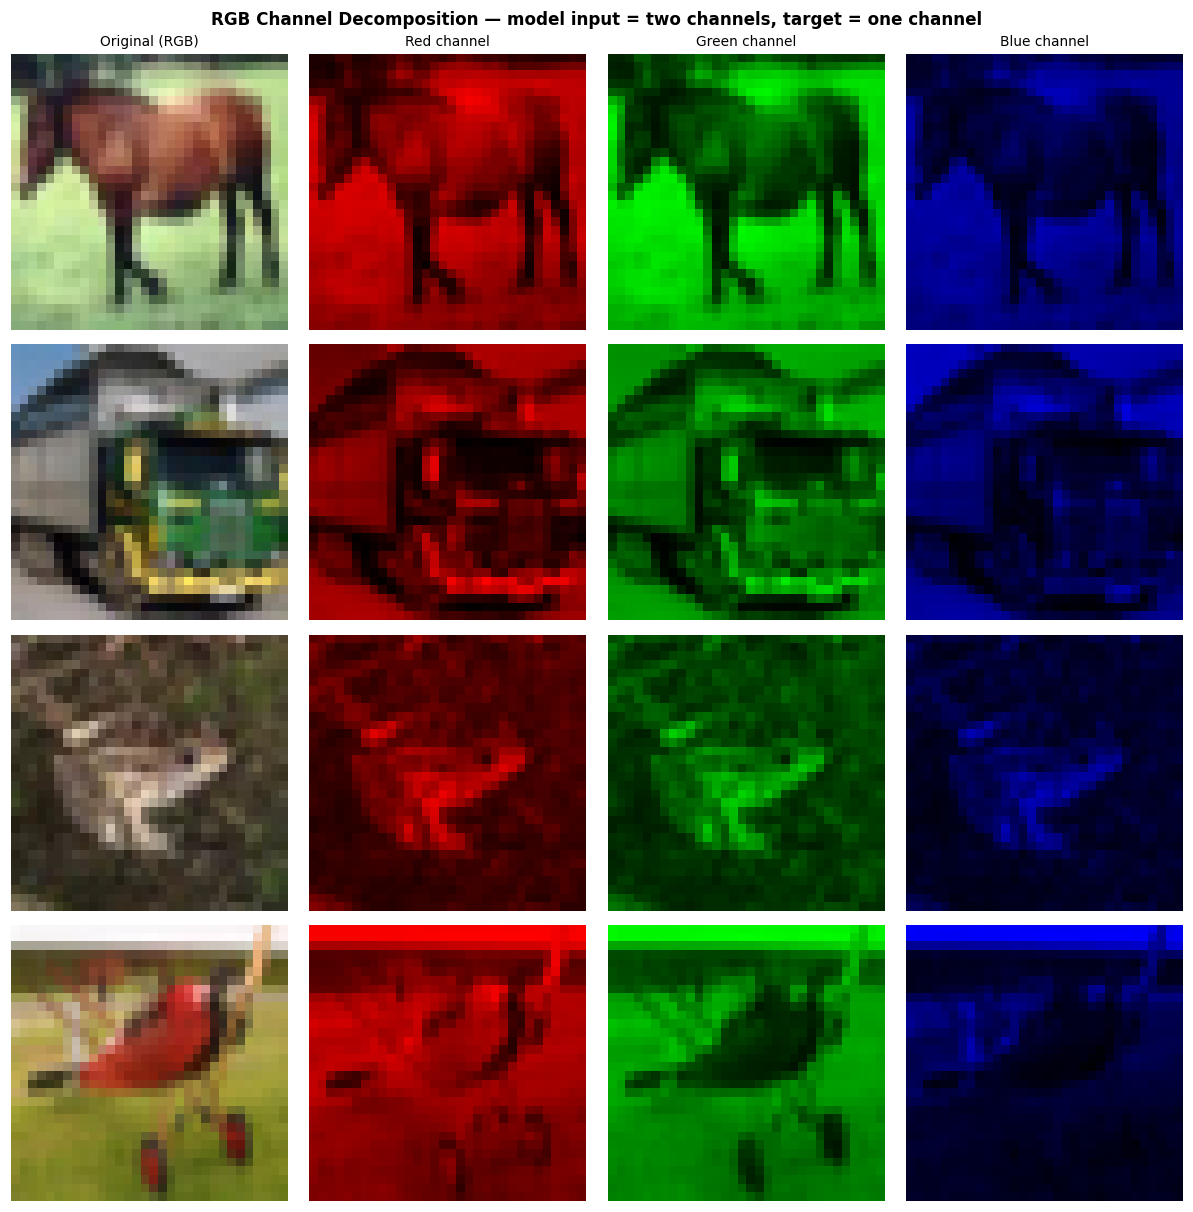

In [109]:
# Pick 4 varied examples
demo_indices = [7, 14, 22, 35]

fig, axes = plt.subplots(len(demo_indices), 4, figsize=(11, 2.8 * len(demo_indices)))
col_titles = ['Original (RGB)', 'Red channel', 'Green channel', 'Blue channel']

for row, si in enumerate(demo_indices):
    img = images[si]                # (3, 32, 32)
    rgb = img.permute(1,2,0).numpy()

    axes[row, 0].imshow(rgb)
    for ch_i, cmap in enumerate(['Reds', 'Greens', 'Blues']):
        plane = np.zeros((32, 32, 3), dtype=np.float32)
        plane[:, :, ch_i] = img[ch_i].numpy()
        axes[row, ch_i+1].imshow(plane, vmin=0, vmax=1)

    for col, title in enumerate(col_titles):
        axes[row, col].set_title(title if row == 0 else '', fontsize=9)
        axes[row, col].set_ylabel(class_names[labels[si]], fontsize=8,
                                   rotation=0, labelpad=50, va='center') if col == 0 else None
        axes[row, col].axis('off')

fig.suptitle('RGB Channel Decomposition — model input = two channels, target = one channel',
             fontsize=11, fontweight='bold')
plt.tight_layout()
show_fig(fig)


### 1-F  Pixel-Value Distributions


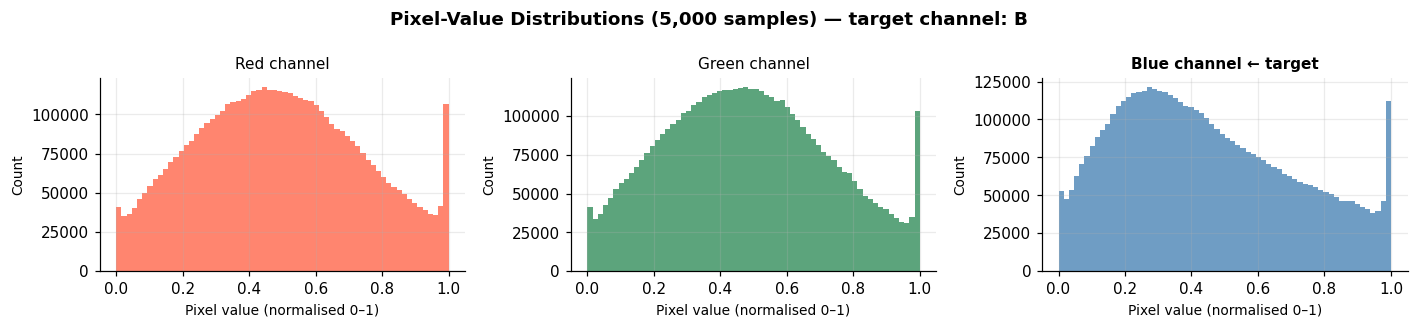

In [110]:
sample_imgs = images[:5000]   # first 5000 images
target      = cfg.TARGET_CHANNEL

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
channel_info = [('Red', 'R', 'tomato'), ('Green', 'G', 'seagreen'), ('Blue', 'B', 'steelblue')]

for ax, (name, ch, color) in zip(axes, channel_info):
    vals = sample_imgs[:, CHANNEL_IDX[ch]].numpy().ravel()
    ax.hist(vals, bins=64, color=color, alpha=0.78, edgecolor='none')
    ax.set_title(f'{name} channel' + (' ← target' if ch == target else ''),
                 fontsize=10, fontweight='bold' if ch == target else 'normal')
    ax.set_xlabel('Pixel value (normalised 0–1)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Pixel-Value Distributions (5,000 samples) — target channel: {target}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
show_fig(fig)


---
## Part 2 — Model Design and Implementation

### Architecture: `ColorPredictor`

A **fully-convolutional regression network** that preserves the 32×32 spatial
resolution throughout via `padding='same'`.  The final Sigmoid constrains outputs
to [0, 1] to match normalised pixel values.

| Block | Layers | In ch | Out ch | Spatial |
|-------|--------|-------|--------|---------|
| ConvBlock 1 | Conv → [BatchNorm] → LeakyReLU → [Dropout] | 2 | 64 | 32×32 |
| ConvBlock 2 | Conv → [BatchNorm] → LeakyReLU → [Dropout] | 64 | 128 | 32×32 |
| ConvBlock 3 | Conv → [BatchNorm] → LeakyReLU → [Dropout] | 128 | 64 | 32×32 |
| Output | 1×1 Conv → Sigmoid | 64 | 1 | 32×32 |

- **Input:** `(B, 2, 32, 32)` — the two known channels
- **Output:** `(B, 1, 32, 32)` — predicted channel, values ∈ [0, 1]
- **Loss:** MSE (pixel-wise regression)
- **Weight init:** Kaiming-normal (appropriate for LeakyReLU)
- **BatchNorm & Dropout** are independently toggleable for ablation studies


### 2-A  Model Architecture Code


In [111]:
# ── ConvBlock: one reusable block with configurable BN + Dropout ──────────
class ConvBlock(nn.Module):
    """
    Conv2d → [BatchNorm2d] → LeakyReLU → [Dropout2d]
    Both BatchNorm and Dropout are independently toggled via constructor flags.
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout_rate=0.2,
                 use_batchnorm=True, use_dropout=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size,
                            padding='same', bias=not use_batchnorm)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.1, inplace=True))
        if use_dropout and dropout_rate > 0:
            layers.append(nn.Dropout2d(p=dropout_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# ── ColorPredictor: full model ─────────────────────────────────────────────
class ColorPredictor(nn.Module):
    """
    Fully-convolutional model predicting one RGB channel from the other two.
    Input : (B, 2, 32, 32)   Output : (B, 1, 32, 32) in [0, 1]
    """
    def __init__(self, in_channels=2, out_channels=1, dropout_rate=0.2,
                 use_batchnorm=True, use_dropout=True):
        super().__init__()
        self.use_batchnorm = use_batchnorm
        self.use_dropout   = use_dropout
        kw = dict(dropout_rate=dropout_rate,
                  use_batchnorm=use_batchnorm, use_dropout=use_dropout)
        self.block1      = ConvBlock(in_channels, 64,  **kw)
        self.block2      = ConvBlock(64,          128, **kw)
        self.block3      = ConvBlock(128,         64,  **kw)
        self.output_conv = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1, padding='same'),
            nn.Sigmoid(),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.output_conv(self.block3(self.block2(self.block1(x))))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instantiate and inspect ────────────────────────────────────────────────
_model = ColorPredictor()
print(_model)
print(f'\nTotal trainable parameters: {_model.count_parameters():,}')

# Verify I/O shapes
dummy = torch.zeros(4, 2, 32, 32)
out   = _model(dummy)
print(f'Input  shape: {tuple(dummy.shape)}')
print(f'Output shape: {tuple(out.shape)}  (expected (4, 1, 32, 32))')
print(f'Output range: [{out.min():.3f}, {out.max():.3f}]  (should be in [0, 1])')


ColorPredictor(
  (block1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Dropout2d(p=0.2, inplace=False)
    )
  )
  (block2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Dropout2d(p=0.2, inplace=False)
    )
  )
  (block3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Dropout2d(p=0.2, inpla

### 2-B  BatchNorm & Dropout Ablation Toggles

Both regularisation components are independently switchable to allow systematic
ablation studies (see Part 3).


In [112]:
configs = [
    ('Baseline (BN + Drop)',     True,  True),
    ('No BatchNorm',             False, True),
    ('No Dropout',               True,  False),
    ('No BN + No Dropout',       False, False),
]

print(f'{"Configuration":<28} {"BN":>4}  {"Drop":>5}  {"Params":>10}')
print('-' * 55)
for name, bn, drop in configs:
    m = ColorPredictor(use_batchnorm=bn, use_dropout=drop)
    print(f'{name:<28} {str(bn):>4}  {str(drop):>5}  {m.count_parameters():>10,}')


Configuration                  BN   Drop      Params
-------------------------------------------------------
Baseline (BN + Drop)         True   True     149,185
No BatchNorm                 False   True     148,929
No Dropout                   True  False     149,185
No BN + No Dropout           False  False     148,929


---
## Part 3 — Training and Optimization

### Training Setup

Our training pipeline implements several techniques to ensure good generalization:

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Loss | MSELoss | Pixel-wise regression for continuous values |
| Optimizer | Adam (lr=1e-3) | Adaptive learning rates, fast convergence |
| **LR Scheduler** | **ReduceLROnPlateau** (factor=0.5, patience=3) | **Implements early stopping via patience: reduces LR when validation loss plateaus for 3 epochs** |
| Checkpoint Saving | Best validation loss only | Prevents overfitting by keeping only the best model |
| Weight Init | Kaiming-normal | Correct scale for LeakyReLU activations |

**Key Early Stopping Mechanism:**
The `patience` parameter in ReduceLROnPlateau provides effective early stopping:
1. Monitor validation loss every epoch
2. If no improvement for `patience` epochs → reduce LR by `factor`
3. After several reductions → LR becomes too small → training naturally stops
4. This is more flexible than hard early stopping as it gives the model multiple chances to improve at finer learning rates


### 3-A  Preventing Overfitting with Patience

Our training pipeline implements **patience-based early stopping** through PyTorch's 
`ReduceLROnPlateau` scheduler. This approach prevents overfitting in several ways:

1. **Validation Monitoring**: Track validation loss every epoch
2. **Best Checkpoint Saving**: Only save models that improve validation performance
3. **Learning Rate Reduction**: When validation loss plateaus for `patience` epochs, 
   reduce LR by `factor` (e.g., 0.5 = halve the learning rate)
4. **Natural Stopping**: After several LR reductions, learning rate becomes too small 
   for meaningful updates, naturally stopping training

**Key Parameters:**
- `LR_SCHEDULER_PATIENCE = 3`: Wait 3 epochs without improvement before reducing LR
- `LR_SCHEDULER_FACTOR = 0.5`: Multiply LR by 0.5 each time it's reduced

This is equivalent to traditional early stopping but more flexible, as the model 
gets multiple chances to improve at progressively finer learning rates.


In [113]:
# Demo: Simulate ReduceLROnPlateau behavior with patience
# This shows how the scheduler reduces LR when validation loss plateaus

from torch.optim import SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create dummy optimizer and scheduler
dummy_model = torch.nn.Linear(2, 1)
optimizer = SGD(dummy_model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Simulate validation losses over epochs
fake_val_losses = [0.100, 0.080, 0.070, 0.070, 0.071, 0.072, 0.073, 0.074]

print(f'  {"Epoch":>5} | {"Val Loss":>9} | {"Learning Rate":>14} | {"Status":>30}')
print('  ' + '-' * 72)

for epoch, val_loss in enumerate(fake_val_losses, 1):
    current_lr = optimizer.param_groups[0]['lr']
    
    # Determine status message
    if epoch == 1:
        status = "Initial"
    elif val_loss < min(fake_val_losses[:epoch-1]):
        status = "Improvement ✓"
    else:
        status = f"No improvement (plateau)"
    
    print(f'  {epoch:>5} | {val_loss:>9.5f} | {current_lr:>14.6f} | {status:>30}')
    
    # Update scheduler (may reduce LR if patience exceeded)
    scheduler.step(val_loss)
    
    # Check if LR changed
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f'        → LR reduced by factor 0.5 (patience of 3 epochs exceeded)')

print('\n  After multiple LR reductions, learning rate becomes too small')
print('  for meaningful updates, naturally stopping the training process.')


  Epoch |  Val Loss |  Learning Rate |                         Status
  ------------------------------------------------------------------------
      1 |   0.10000 |       0.001000 |                        Initial
      2 |   0.08000 |       0.001000 |                  Improvement ✓
      3 |   0.07000 |       0.001000 |                  Improvement ✓
      4 |   0.07000 |       0.001000 |       No improvement (plateau)
      5 |   0.07100 |       0.001000 |       No improvement (plateau)
      6 |   0.07200 |       0.001000 |       No improvement (plateau)
      7 |   0.07300 |       0.001000 |       No improvement (plateau)
        → LR reduced by factor 0.5 (patience of 3 epochs exceeded)
      8 |   0.07400 |       0.000500 |       No improvement (plateau)

  After multiple LR reductions, learning rate becomes too small
  for meaningful updates, naturally stopping the training process.


### 3-B  Train Model (target = Blue)

Set `force_train=True` to retrain from scratch; the default loads an existing
checkpoint instantly.


In [114]:
# Train the model with patience-based early stopping via ReduceLROnPlateau
# The scheduler's patience parameter (LR_SCHEDULER_PATIENCE=3) provides
# early stopping behavior by reducing LR when validation loss plateaus

model_B, train_losses, val_losses = train(
    target_channel='B',
    num_epochs=cfg.NUM_EPOCHS,
    lr=cfg.LEARNING_RATE,
    force_train=False,   # set True to retrain from scratch
)

if train_losses:
    print(f'Trained for {len(train_losses)} epoch(s) — '
          f'best val_loss = {min(val_losses):.6f}')
    print(f'LR scheduler patience : {cfg.LR_SCHEDULER_PATIENCE} epochs')
else:
    print('Loaded from checkpoint.')
print(f'Config: BN={model_B.use_batchnorm}  Drop={model_B.use_dropout}  '
      f'Params={model_B.count_parameters():,}')


INFO | Checkpoint found at /Users/wang/Documents/deeplearning_assignment2/synesthesia_cifar10/models/best_model_B.pth. Skipping training (use --force-train to retrain).
INFO | Loaded checkpoint from /Users/wang/Documents/deeplearning_assignment2/synesthesia_cifar10/models/best_model_B.pth


Loaded from checkpoint.
Config: BN=True  Drop=True  Params=149,185


### 3-C  Training Curves


In [115]:
curve_path = cfg.OUTPUTS_DIR / 'loss_curve_B.png'

if train_losses:
    # Plot fresh curves from this training run
    epochs = range(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, train_losses, label='Train loss', linewidth=2, color='steelblue')
    ax.plot(epochs, val_losses,   label='Val loss',   linewidth=2,
            linestyle='--', color='tomato')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title("Training / Validation Loss  —  target='B'",
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    # Save for record
    fig.savefig(curve_path, dpi=120, bbox_inches='tight')
    show_fig(fig)
    print(f'LR scheduler with patience: ReduceLROnPlateau')
    print(f'  - Patience: {cfg.LR_SCHEDULER_PATIENCE} epochs (wait before reducing LR)')
    print(f'  - Factor  : {cfg.LR_SCHEDULER_FACTOR} (LR multiplier on plateau)')
    print(f'  → This provides early stopping behavior by reducing LR when val loss plateaus')
elif curve_path.exists():
    display(Image(str(curve_path)))
else:
    print('No training history — run with force_train=True to generate curves.')


No training history — run with force_train=True to generate curves.


### 3-D  Hyperparameter Ablation Study

Four configurations are trained for `NUM_EPOCHS` each on the **same** data split
to systematically isolate the effects of **BatchNorm** and **Dropout** at a fixed learning rate.

**Fixed:** Learning Rate = **1e-2**

| # | Config | LR | BatchNorm | Dropout | p |
|---|--------|----|-----------|---------|---|
| 1 | No BN, No Dropout | 1e-2 | ✗ | ✗ | 0.0 |
| 2 | BN only | 1e-2 | ✓ | ✗ | 0.0 |
| 3 | Dropout only | 1e-2 | ✗ | ✓ | 0.2 |
| 4 | BN + Dropout | 1e-2 | ✓ | ✓ | 0.2 |

This **2×2 ablation design** allows us to observe:
- The individual effect of BatchNorm
- The individual effect of Dropout
- Whether they have synergistic or antagonistic interactions

> **Note:** Increase `NUM_EPOCHS` in `src/config.py` (or pass `--epochs N` on the CLI)
> for a more thorough sweep. The default value is kept low for a quick demo.


In [116]:
sweep_plot = cfg.OUTPUTS_DIR / 'hyperparameter_comparison_B.png'
sweep_csv  = cfg.OUTPUTS_DIR / 'hyperparameter_results_B.csv'

if sweep_plot.exists():
    print('Sweep results already found — displaying saved plots.')
else:
    print('Running sweep... (this may take a few minutes)')
    sweep_results = run_sweep(target_channel='B', num_epochs=cfg.NUM_EPOCHS)

display(Image(str(sweep_plot)))


INFO | === Hyperparameter Sweep  target='B'  epochs=5  configs=7 ===


INFO | Building data loaders …
INFO | Loading data_batch_1 …
INFO | Loading data_batch_2 …


Running sweep... (this may take a few minutes)


INFO | Loading data_batch_3 …
INFO | Loading data_batch_4 …
INFO | Loading data_batch_5 …
INFO | Loaded 50,000 images  shape=(50000, 3, 32, 32)
INFO | Split — train: 40,000  val: 5,000  test: 5,000  target='B'
INFO |   ▶ 'Baseline'                      lr=0.001  BN=True  Drop=True  p=0.2
INFO |     ↳ best val_loss=0.011331  time=73.8s                                         
INFO |   ▶ 'High LR (1e-2)'                lr=0.01  BN=True  Drop=True  p=0.2


KeyboardInterrupt: 

In [ ]:
# Print ranked results table
import csv

if sweep_csv.exists():
    with open(sweep_csv) as f:
        reader = csv.DictReader(f)
        rows = sorted(reader, key=lambda r: float(r['best_val_loss']))

    print(f'  {"Rank":>4}  {"Configuration":<25} {"LR":>7}  {"BN":>3}  '
          f'{"Drop":>4}  {"p":>4}  {"Best Val MSE":>13}')
    print('  ' + '-' * 70)
    for rank, r in enumerate(rows, 1):
        print(f'  {rank:>4}  {r["name"]:<25} {float(r["lr"]):>7.0e}  '
              f'{r["use_batchnorm"]:>3}  {r["use_dropout"]:>4}  '
              f'{float(r["dropout_rate"]):>4.1f}  '
              f'{float(r["best_val_loss"]):>13.6f}')
    print('\nKey findings:')
    best = rows[0]
    worst = rows[-1]
    print(f'  Best  : {best["name"]}  (val_MSE={float(best["best_val_loss"]):.6f})')
    print(f'  Worst : {worst["name"]}  (val_MSE={float(worst["best_val_loss"]):.6f})')


---
## Part 4 — Evaluation and Analysis

The trained model is evaluated on the held-out **test set** (10% of training data, 5,000 images).

| Metric | Formula | Better when |
|--------|---------|-------------|
| MSE | mean((ŷ − y)²) | Lower |
| MAE | mean(\|ŷ − y\|) | Lower |
| PSNR | 10·log₁₀(1 / MSE) dB | Higher (>30 dB is good) |
| SSIM | structural similarity ∈ [−1, 1] | Closer to 1 |


### 4-A  Build Test Loader


In [ ]:
_, _, test_loader = build_dataloaders(target_channel='B')
print(f'Test batches : {len(test_loader)}')
print(f'Test images  : {len(test_loader.dataset):,}')


### 4-B  Quantitative Metrics


In [ ]:
metrics = compute_metrics(model_B, test_loader, 'B')

print('\nTest Set Metrics  (target=B, predict Blue from Red+Green)')
print('-' * 50)
for k, v in metrics.items():
    unit = ' dB' if k == 'PSNR' else ''
    print(f'  {k:<6}: {v:.4f}{unit}')


### 4-C  Visual Comparisons: Original vs Reconstructed vs |Difference|

Each row shows one test image with:
- **Original** — ground truth RGB
- **Reconstructed** — R+G channels kept, B channel replaced by model prediction
- **|Difference|** — absolute per-pixel error (hotter = worse)


In [ ]:
model_B.eval()
target_idx    = CHANNEL_IDX['B']
input_indices = [i for i in range(3) if i != target_idx]
n_samples     = 10

x_batch, y_batch, lbls, fulls = next(iter(test_loader))
x_s, y_s     = x_batch[:n_samples], y_batch[:n_samples]
fulls_s, lbls_s = fulls[:n_samples], lbls[:n_samples]

with torch.no_grad():
    preds = model_B(x_s.to(cfg.DEVICE)).cpu()

fig, axes = plt.subplots(n_samples, 3, figsize=(8, n_samples * 2.0))
fig.suptitle(
    'Predictions  |  Target: Blue  |  Inputs: Red + Green\n'
    'Original  ·  Reconstructed  ·  |Difference|',
    fontsize=11, fontweight='bold', y=1.01,
)

for i in range(n_samples):
    orig  = fulls_s[i].permute(1, 2, 0).numpy()

    # Reconstruct: keep input channels, insert predicted channel
    recon = np.zeros((32, 32, 3), dtype=np.float32)
    inp_np = x_s[i].numpy()
    recon[:, :, input_indices[0]] = inp_np[0]
    recon[:, :, input_indices[1]] = inp_np[1]
    recon[:, :, target_idx]       = preds[i, 0].numpy()

    diff = np.abs(orig - recon)

    axes[i, 0].imshow(np.clip(orig,  0, 1))
    axes[i, 1].imshow(np.clip(recon, 0, 1))
    im = axes[i, 2].imshow(diff.mean(axis=2), vmin=0, vmax=0.5, cmap='hot')

    cls = CIFAR10_CLASSES[int(lbls_s[i])]
    axes[i, 0].set_ylabel(cls, fontsize=8, rotation=0, labelpad=48, va='center')
    for j, title in enumerate(['Original', 'Reconstructed', '|Diff|']):
        if i == 0:
            axes[i, j].set_title(title, fontsize=9)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Absolute error')
plt.tight_layout()
show_fig(fig)


### 4-D  Performance Matrix: Best / Mean / Worst Predictions

All test images are sorted by per-image MSE.  Four examples are sampled from
each tier — **Best** (lowest MSE), **Mean** (median MSE), and **Worst** (highest MSE) —
revealing what the model handles well and poorly.


In [ ]:
matrix_path = plot_performance_matrix(model_B, test_loader, 'B', n_per_tier=4)
display(Image(str(matrix_path)))


### 4-E  Per-Class Analysis

MSE and PSNR are computed separately for each CIFAR-10 class to identify
which object categories the model handles well or poorly.


In [ ]:
perclass_path = plot_per_class_metrics(model_B, test_loader, 'B')
display(Image(str(perclass_path)))


---
## Bonus — Predict All Three Channels (R, G, B)

A separate model is trained for each target channel:

| Target | Inputs | Task |
|--------|--------|------|
| R | G + B | Predict Red from Green and Blue |
| G | R + B | Predict Green from Red and Blue |
| B | R + G | Predict Blue from Red and Green (main task) |

This lets us compare which channel is hardest to predict.


In [ ]:
all_metrics = {}
for ch in ['R', 'G', 'B']:
    print(f'\n── Channel {ch} ──────────────────────────────────────')
    m, _, _ = train(target_channel=ch, num_epochs=cfg.NUM_EPOCHS, force_train=False)
    _, _, tl = build_dataloaders(ch)
    all_metrics[ch] = compute_metrics(m, tl, ch)

print('\n\nAll-Channel Comparison (test set)')
print('=' * 62)
print(f'  {"Target":>8} | {"MSE":>10} | {"MAE":>10} | {"PSNR (dB)":>10} | {"SSIM":>8}')
print('  ' + '-' * 57)
for ch, met in all_metrics.items():
    inputs = '+'.join(c for c in 'RGB' if c != ch)
    print(f'  {inputs}→{ch:>2}    | {met["MSE"]:>10.6f} | {met["MAE"]:>10.6f} | '
          f'{met["PSNR"]:>10.4f} | {met["SSIM"]:>8.4f}')
print('=' * 62)


In [ ]:
# Visual comparison: one example reconstructed with all three target channels
x_b, y_b, lbls_b, fulls_b = next(iter(build_dataloaders('B')[2]))
sample_i = 3
orig_rgb = fulls_b[sample_i].permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle('Bonus: Full-Image Reconstruction from Each Target Channel',
             fontsize=12, fontweight='bold')

axes[0, 0].imshow(np.clip(orig_rgb, 0, 1))
axes[0, 0].set_title('Ground Truth', fontsize=10, fontweight='bold')
axes[1, 0].axis('off')

for col, ch in enumerate(['R', 'G', 'B'], 1):
    ch_model, _, _ = train(ch, force_train=False)
    ch_model.eval()

    ch_idx    = CHANNEL_IDX[ch]
    in_idx    = [i for i in range(3) if i != ch_idx]
    ch_loader = build_dataloaders(ch)[2]

    xb, yb, _, fb = next(iter(ch_loader))
    with torch.no_grad():
        pred_ch = ch_model(xb[sample_i:sample_i+1].to(cfg.DEVICE)).cpu()

    recon = np.zeros((32, 32, 3), dtype=np.float32)
    inp_np = xb[sample_i].numpy()
    recon[:, :, in_idx[0]] = inp_np[0]
    recon[:, :, in_idx[1]] = inp_np[1]
    recon[:, :, ch_idx]    = pred_ch[0, 0].numpy()

    gt = fb[sample_i].permute(1, 2, 0).numpy()
    diff = np.abs(gt - recon)

    mse_v = float(np.mean((pred_ch[0,0].numpy() - yb[sample_i,0].numpy())**2))
    inputs_str = '+'.join(c for c in 'RGB' if c != ch)

    axes[0, col].imshow(np.clip(recon, 0, 1))
    axes[0, col].set_title(f'Predict {ch} from {inputs_str}\nMSE={mse_v:.4f}', fontsize=9)
    axes[1, col].imshow(diff.mean(axis=2), vmin=0, vmax=0.4, cmap='hot')
    axes[1, col].set_title(f'|Diff| (mean abs error)', fontsize=8)

axes[1, 0].text(0.5, 0.5, f'Class: {CIFAR10_CLASSES[int(lbls_b[sample_i])]}',
                ha='center', va='center', transform=axes[1,0].transAxes, fontsize=10)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
show_fig(fig)
